In [1]:
print("Everything is okay!!!")

Everything is okay!!!


In [2]:
# Step 1: Define the state schema

# Define a TypedDict for defining state structure/schema
# and Annotated for type hinting with context-specific metadata
# add_messages to handle message passing in the graph - it merges two list of messages Reducer to manage state transitions

from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:

# StateGraph, START, END to create the graph workflow
from langgraph.graph import StateGraph, START, END

In [4]:
# Load environment variables from a .env file
# As i will be using API keys from environment variables to run LLMs from LangChain openai and groq

import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

# Now you can access your environment variables using os.getenv
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("Environment variables loaded successfully.")

Environment variables loaded successfully.


In [5]:
# load necessary LLMs  from langchain
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model = "gpt-4o")
llm.invoke("Hello")  # Test the LLM to ensure it's working                 

d:\GENAIBatch\langchain_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1ceab21c9a', 'id': 'chatcmpl-DW2P46teXp1aGFS896t6TApP0qnwj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da153-a175-78f0-81eb-2c2e0eda5dd6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
# load LLMs from langchain-groq

from langchain_groq import ChatGroq

groq_llm = ChatGroq(model = "qwen/qwen3-32b")
groq_llm.invoke("Hey I am Anant and i like to develop AI models")  # Test the Groq LLM to ensure it's working

AIMessage(content='<think>\nOkay, so Anant mentioned he likes to develop AI models. Let me think about how to respond. He might be looking for advice, resources, or encouragement. First, I should acknowledge his interest positively. Maybe ask how long he\'s been into it to get a sense of his experience level.\n\nI should consider different ways to support him. If he\'s a beginner, suggesting online courses, tutorials, or communities could be helpful. For example, mentioning platforms like Coursera or Andrew Ng\'s courses. If he\'s more advanced, perhaps discussing specific frameworks like TensorFlow or PyTorch, or even hardware considerations like GPUs.\n\nI need to be careful not to assume his current skill level. Maybe ask a question to clarify. Also, offering to help with specific projects or problems he\'s working on could be valuable. Maybe list some common challenges in AI development, like data preprocessing, model selection, or deployment, and see if he\'s facing any of those.\

In [7]:
# Create node
def saktimaan(state:State):
    return {"messages": [groq_llm.invoke(state["messages"])]}

In [8]:
# StateGraph to define the workflow

workflow = StateGraph(State)

# add nodes to the workflow
workflow.add_node("Saktimaan", saktimaan)

# define the edges with START and END
workflow.add_edge(START, "Saktimaan")
workflow.add_edge("Saktimaan", END)

# compile the workflow
compiled_workflow = workflow.compile()
print("Workflow compiled successfully.")

Workflow compiled successfully.


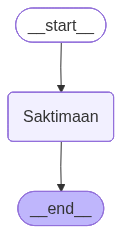

In [9]:
# display the workflow
from IPython.display import display, Image

display(Image(compiled_workflow.get_graph().draw_mermaid_png()))

In [10]:
# invoke the workflow with initial messages
compiled_workflow.invoke({"messages":"What is Agentic AI?"})

{'messages': [HumanMessage(content='What is Agentic AI?', additional_kwargs={}, response_metadata={}, id='589b2d77-3493-43b7-8059-b86d84cde21a'),
  AIMessage(content='<think>\nOkay, so I need to figure out what Agentic AI is. Let me start by breaking down the term. The word "agentic" sounds like it\'s related to "agency," which I know means the capacity to act independently. So Agentic AI probably refers to an AI that has some level of autonomy or agency. But I\'m not entirely sure. Maybe it\'s an AI that can make decisions on its own?\n\nI remember hearing about AI systems that can plan, reason, or execute tasks without constant human input. For example, a robot that navigates a room to pick up objects would need some autonomy. So maybe Agentic AI is a system that can perform such tasks independently. But how does that differ from other AI systems?\n\nLet me think about traditional AI applications. There\'s AI for image recognition, like identifying a cat in a photo. That\'s more abou

In [16]:
# invoke the workflow with initial messages
compiled_workflow.invoke({"messages":"what is 5 plus 5?"})

{'messages': [HumanMessage(content='what is 5 plus 5?', additional_kwargs={}, response_metadata={}, id='95b6f75d-14c8-4269-a4c3-a9a82b709b0d'),
  AIMessage(content='<think>\nOkay, the user is asking "what is 5 plus 5?" Let me think about how to approach this. First, this is a basic arithmetic question, so the answer should be straightforward. The fundamental operation here is addition. \n\nStarting with the numbers 5 and 5, adding them together is a simple process. In the decimal system, when you add 5 and 5, you get 10. I should verify that there are no tricks or hidden elements in the question. The user might be testing if I recognize any alternate interpretations, but "plus" here definitely refers to standard addition.\n\nI should consider if there\'s any context where "5 plus 5" could mean something else. For example, in modular arithmetic, like modulo 10, 5 + 5 would be 0, but the user didn\'t specify that. Since there\'s no indication of a different number system or context, stic

In [17]:
# invoke the workflow with initial messages
compiled_workflow.invoke({"messages":"add 5 to the previous result and tell me the answer?"})

{'messages': [HumanMessage(content='add 5 to the previous result and tell me the answer?', additional_kwargs={}, response_metadata={}, id='eb4eac6a-42bd-4eba-9c1f-2a1204070222'),
  AIMessage(content='<think>\nOkay, let me try to figure this out. The user is asking to "add 5 to the previous result and tell me the answer." Hmm, but I need to check if there\'s a previous result from a prior conversation. Wait, I just started this interaction, right? The user hasn\'t given me any numbers or results to work with before this question. So if there\'s no previous result, how can I add 5 to it?\n\nMaybe the user is referring to a result from a calculation they did earlier, but they haven\'t shared it with me yet. Or perhaps they made a mistake and forgot to provide the initial number. Without knowing what the previous result is, I can\'t perform the addition. Let me make sure I\'m not missing any context. Since this is the first message in our conversation, there\'s definitely no prior result s

In [12]:
# Streaming the responses from the workflow
compiled_workflow.stream({"messages":"Explain Agentic AI in detail."})

<generator object Pregel.stream at 0x000001AC3EE70310>

In [13]:
# Streaming the responses from the workflow
for chunk in compiled_workflow.stream({"messages":"Explain Agentic AI in detail."}):
    print(chunk)

{'Saktimaan': {'messages': [AIMessage(content='<think>\nOkay, I need to explain agentic AI in detail. Let me start by recalling what I know about AI. There\'s traditional AI, which is more about passive systems performing tasks like image recognition or language translation. Agentic AI probably refers to AI that acts more autonomously. Maybe it has goals, can make decisions, learn from experiences, and adapt?\n\nWait, I should define agentic AI clearly. The term \'agent\' in computer science usually refers to a program that can perform tasks autonomously. So agentic AI would be AI systems designed to act as agents. But what distinguishes agentic AI from other AI systems? Maybe it\'s about autonomy, proactiveness, reactivity, and social ability. Those are characteristics of software agents.\n\nAutonomy means the AI can operate without human intervention. Proactiveness implies it can take initiative, like setting goals and pursuing them. Reactivity means responding to environmental chang

- You would have noticed that here with stream only I get the last message but in the previous example all messages was there so is there any way to get both? 
- Ans is yes.

In [14]:
# Streaming the responses from the workflow
# stream_mode = "values" is a setting in LangGraph that tells the graph to emit the full, updated state of the application after every single node execution (super-step).

for chunk in compiled_workflow.stream({"messages":"Explain Agentic AI in detail."}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Explain Agentic AI in detail.', additional_kwargs={}, response_metadata={}, id='fbfc10e9-b7e2-47e8-83d6-bd29d77758c8')]}
{'messages': [HumanMessage(content='Explain Agentic AI in detail.', additional_kwargs={}, response_metadata={}, id='fbfc10e9-b7e2-47e8-83d6-bd29d77758c8'), AIMessage(content='<think>\nOkay, I need to explain what Agentic AI is. Let me start by recalling what I know. AI has evolved from simple rule-based systems to more complex models like machine learning and deep learning. Now, there\'s this term "Agentic AI" that\'s being talked about. I think it refers to an AI system that acts autonomously. But wait, isn\'t that what AI has been doing for a while? Maybe it\'s a step beyond that. \n\nLet me break it down. The word "agent" in AI usually refers to an entity that can perceive its environment and take actions to achieve goals. So an agentic AI would be an AI that can act as an agent, right? But traditional AI agents might not have a

In [15]:
# Streaming the responses from the workflow
# In LangGraph, stream_mode="updates" is a streaming configuration that instructs the graph to emit only the specific state changes (updates) produced by each node after it executes
for chunk in compiled_workflow.stream({"messages":"Explain Agentic AI in detail."}, stream_mode="updates"):
    print(chunk)

{'Saktimaan': {'messages': [AIMessage(content='<think>\nOkay, so I need to explain Agentic AI in detail. Hmm, let\'s start by breaking down the term. "Agentic" refers to something having agency, right? So maybe Agentic AI is AI that has some level of autonomy or decision-making capability. But I\'m not entirely sure. Let me think.\n\nI remember hearing about autonomous agents in AI before. They\'re systems that can operate independently to achieve goals. So Agentic AI could be an advanced form of that. Maybe it combines machine learning with some planning and decision-making abilities. But how exactly does that work?\n\nWait, there\'s also the concept of AI agents. Like in games, there are non-player characters that act autonomously. But Agentic AI might be more sophisticated. Perhaps it\'s about AI that can take initiative, learn from its environment, adapt, and make decisions without constant human intervention. That sounds plausible.\n\nI should check if there\'s a specific framewor